# 2$^a$ Tarefa de Oficina de Modelagem

**Autor:** Arthur Vinícius de Oliveira Carvalho  
**Instituição:** UFMG  
**Data:** 18 de março de 2026  

---

## Descrição
Exercícios computacionais

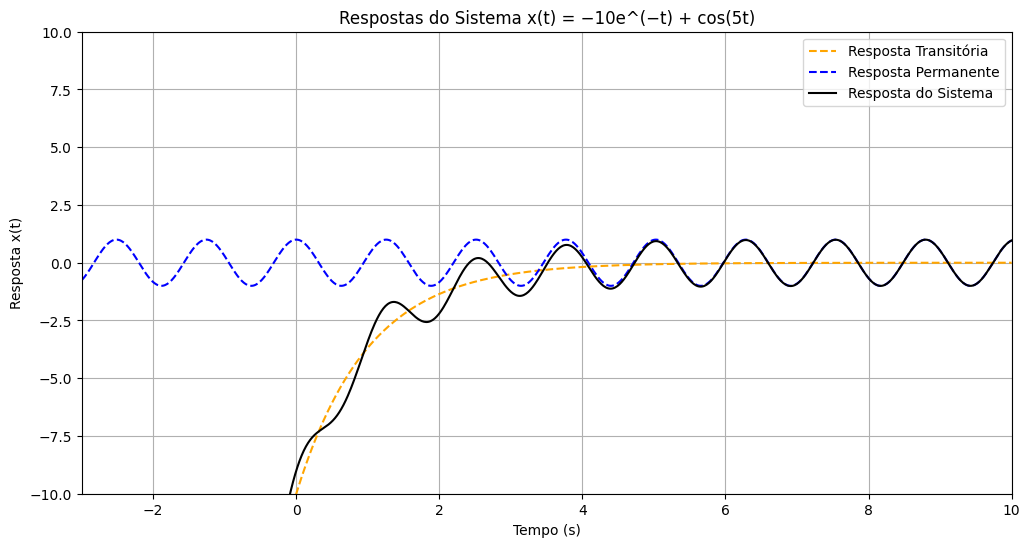

In [1]:
import numpy as np
import matplotlib.pyplot as plt

"""

    1. Suponha que a resposta de um sistema dinˆamico seja dado por:

        x(t) = −10e^(−t) + cos(5t)


    - Achar a resposta transitória e a resposta permanente.

        Resposta: A resposta transitório é aaquela que tende a zero quando t → ∞, ou seja, −10e^(−t).
        Já a resposta permanente é aquela que permanece quando t → ∞, ou seja, cos(5t).


    - Plotar a resposta transitória, a resposta permanente e a resposta do sistema em uma
    mesma figura usando Matlab. (como foi permitido pelo professor, usaremos python).

"""

# Tempo de 0 a 10 segundos
t = np.linspace(-5, 10, 1000)

# resposta transitória
x_tr = -10*np.exp(-t)

# resposta permanente
x_pm = np.cos(5*t)

# resposta do sistema
x = x_tr + x_pm

# Plotando as respostas
plt.figure(figsize=(12, 6))

plt.plot(t, x_tr, label='Resposta Transitória', linestyle='--', color='orange')
plt.plot(t, x_pm, label='Resposta Permanente', linestyle='--', color='blue')
plt.plot(t, x, label='Resposta do Sistema', color='black')

plt.ylim(-10, 10)
plt.xlim(-3, 10)

plt.xlabel("Tempo (s)")
plt.ylabel("Resposta x(t)")
plt.title("Respostas do Sistema x(t) = −10e^(−t) + cos(5t)")
plt.legend()
plt.grid()

plt.show()

Função de transferência G(s):
      1       
──────────────
             2
c⋅s + k + m⋅s 


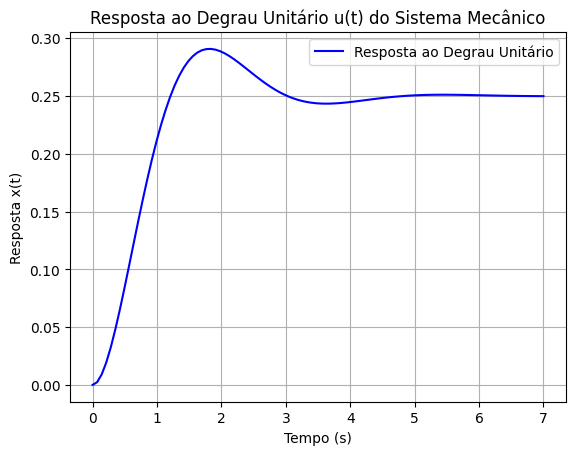

In [2]:
import numpy as np
import sympy as sp
from scipy import signal
import matplotlib.pyplot as plt

"""
    2. O modelo matem´atico de sistemas mecânicos com 1GDL com apenas uma massa m, uma
    mola k e um amortecedor c é dado pela EDOL

                            m*x'' + c*x' + k*x = F(t)

    sendo x(t) a resposta no tempo e f(t) a excitação.


    - Calcular a função de transferência do sistema.

    - Mostrá-la  de forma simbólica usando Matlab. Nota: usar o comando pretty.
    (usaremos python e a biblioteca sympy para isso e o comando pprint, que é equivalente ao pretty).

    - Aplicar uma excitação do tipo degrau unitário e apresentar a resposta x(t) de forma
    gráfica. Assumir os seguintes parâmetros do sistema: m = 1kg, c = 2N.s/m e
    k = 4N/m. Nota: Simular usando o comando step do Matlab.
    (Também usaremos python)
"""
"""
    Calculo da Função de transferência:

        EDO - m*x'' + c*x' + k*x = f(t)
        LT - m*s^2*X(s) + c*s*X(s) + k*X(s) = F(s)
        Fatoriando - > X(s)*(m*s^2 + c*s + k) = F(s)

        Função de transferência - > G(s) = X(s)/F(s) = 1/(m*s^2 + c*s + k)
"""
#----------SEGUNDO ITEM----------
#variáveis simbólicas
s, m, c, k = sp.symbols('s m c k')

#função de transferência
G = 1/(m*s**2 + c*s + k)

#mostrar simpolicamente
print("Função de transferência G(s):")
sp.pprint(G)

#----------TERCEIRO ITEM----------
#parâmetros do sistema
m = 1  # kg
c = 2  # N.s/m
k = 4  # N/m

num = [1]  # Numerador da função de transferência
dem = [m, c, k]  # Denominador da função de transferência

sistema = signal.TransferFunction(num, dem)

t, resposta = signal.step(sistema)

# Plotar a resposta ao degrau
plt.figure()
plt.plot(t, resposta, label='Resposta ao Degrau Unitário', color='blue')
plt.xlabel('Tempo (s)')
plt.ylabel('Resposta x(t)')
plt.title('Resposta ao Degrau Unitário u(t) do Sistema Mecânico')
plt.legend()
plt.grid(True)

plt.show()


Função de transferência G(s):
   c⋅s + k    
──────────────
             2
c⋅s + k + m⋅s 


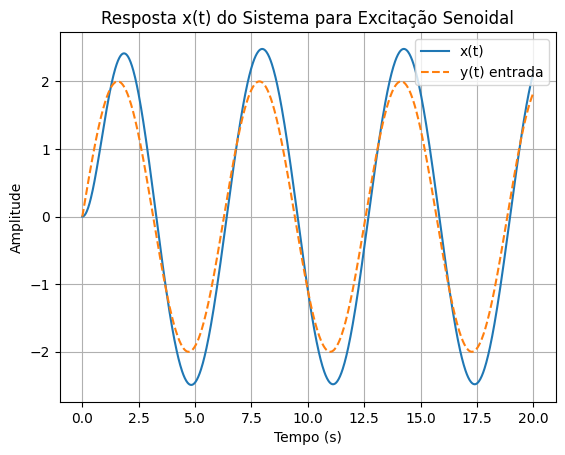

In [3]:
import numpy as np
import sympy as sp
from scipy import signal
import matplotlib.pyplot as plt

"""

    O modelo matemático do sistema mecânico da Figura 18 á dado por

                            mx'' + cx' + kx = cy' + ky

    sendo x(t) o deslocamento da massa ao longo do tempo e y(t) é a
    excitação do tipo deslocamento da base.

    • Calcular a função de transferência do sistema.

    • Mostrá-la de forma simbólica usando Matlab. (Usaremos python/sympy)

    • Aplicar ao sistema uma excitação senoidal com amplitude 2 e frequência 1 rad/s.
    Apresentar a resposta x(t) de forma gráfica. Assumir os seguintes parâmetros do
    sistema: m = 1 kg, c = 2 N.s/m e k = 4 N/m.

    • Calcular a resposta temporal x(t) para a entrada do item anterior.

"""


#Resolução do 1° Item
"""
    EDO - mx'' + cx' + kx = cy' + ky
    LT - m*s^2*X(s) + c*s*X(s) + k*X(s) = c*s*Y(s) + k*Y(s)
    Fatoriando - > X(s)*(m*s^2 + c*s + k) = Y(s)*(c*s + k)

    Função de transferência - > G(s) = X(s)/Y(s) = (c*s + k)/(m*s^2 + c*s + k)
"""


#Resolução do 2° Item
s, m, c, k = sp.symbols('s m c k') #Variaveis simbólicas
G = (c*s + k)/(m*s**2 + c*s + k) #Função de transferência
print("Função de transferência G(s):")
sp.pprint(G)


#Resolução do 3° Item
"""
    m = 1 kg, c = 2 N.s/m e k = 4 N/m.
    G = (2s + 4)/(s^2 + 2s + 4)
"""
m = 1
c = 2
k = 4

num = [c, k] # Numerador da função de transferência
dem = [m, c, k] # Denominador da função de transferência

sistema = signal.TransferFunction(num, dem)

t = np.linspace(0, 20, 1000)

y = 2*np.sin(t) #frequencia 1 e amplitude 2

t_out, x, _ = signal.lsim(sistema, U=y, T=t) # lsim calcula a saída de um sistema submetido a qualquer
                                             # entrada, nesse caso a entrada é a função senoidal
                                             # y(t) = 2*sin(t)

plt.figure()
plt.plot(t_out, x, label="x(t)")
plt.plot(t, y, label="y(t) entrada", linestyle='--')
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("Resposta x(t) do Sistema para Excitação Senoidal")
plt.legend()
plt.grid()

plt.show()



Transformada de Laplace F(s):

⎛⎧     -s           -s                            ⎞   ⎛⎧   -s      -s      -2⋅ ↪
⎜⎪  2⋅ℯ     2    2⋅ℯ                              ⎟   ⎜⎪2⋅ℯ     2⋅ℯ     2⋅ℯ    ↪
⎜⎪- ───── + ── - ─────  for s > -∞ ∧ s < ∞ ∧ s ≠ 0⎟   ⎜⎪───── - ───── + ────── ↪
⎜⎨    s      2     2                              ⎟ + ⎜⎨  s       2        2   ↪
⎜⎪          s     s                               ⎟   ⎜⎪         s        s    ↪
⎜⎪                                                ⎟   ⎜⎪                       ↪
⎝⎩         1                    otherwise         ⎠   ⎝⎩           1           ↪

↪ s                            ⎞
↪                              ⎟
↪ ─  for s > -∞ ∧ s < ∞ ∧ s ≠ 0⎟
↪                              ⎟
↪                              ⎟
↪                              ⎟
↪            otherwise         ⎠


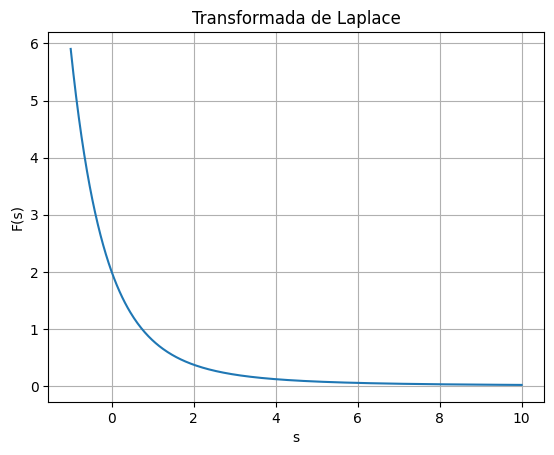

In [4]:
import numpy as np
import sympy as sp
from scipy import signal
import matplotlib.pyplot as plt

"""

    5. Calcular a Transformada de Laplace do pulso triangular da Figura 20 e simulá-lo usando
    Matlab. (usaremos pyhton)

    0 para t < 0
    cresce linearmente de 0 até 2 entre 0 e 1
    decresce linearmente de 2 até 0 entre 1 e 2
    0 para t > 2

    Entre 0 e 1, a função é dada por f(t) = 2t
    Entre 1 e 2, a função é dada por f(t) = -2t + 4

"""

#simbolos
t, s = sp.symbols('t s')

#partes da função
f1 = 2*t
f2 = -2*t + 4

#Transformadas de Laplace
F1 = sp.integrate(f1*sp.exp(-s*t), (t, 0, 1))
F2 = sp.integrate(f2*sp.exp(-s*t), (t, 1, 2))
F = F1 + F2

# simplificar
F = sp.factor(F)
print("Transformada de Laplace F(s):\n")
sp.pprint(F)

F = (2*(1-sp.exp(-s))**2)/(s**2) #versão simplificada da transformada de Laplace, obtida usando o comando simplify do sympy

# transformar em função numérica
F_func = sp.lambdify(s, F, 'numpy')

s_vals = np.linspace(-1,10,500)

plt.plot(s_vals, F_func(s_vals))

plt.xlabel("s")
plt.ylabel("F(s)")
plt.title("Transformada de Laplace")

plt.grid()
plt.show()

Transformada de Laplace F(s):

⎧        -s           -s                            
⎪4    4⋅ℯ     8    8⋅ℯ                              
⎪── + ───── - ── + ─────  for s > -∞ ∧ s < ∞ ∧ s ≠ 0
⎨ 2     2      3     3                              
⎪s     s      s     s                               
⎪                                                   
⎩          2/3                    otherwise         


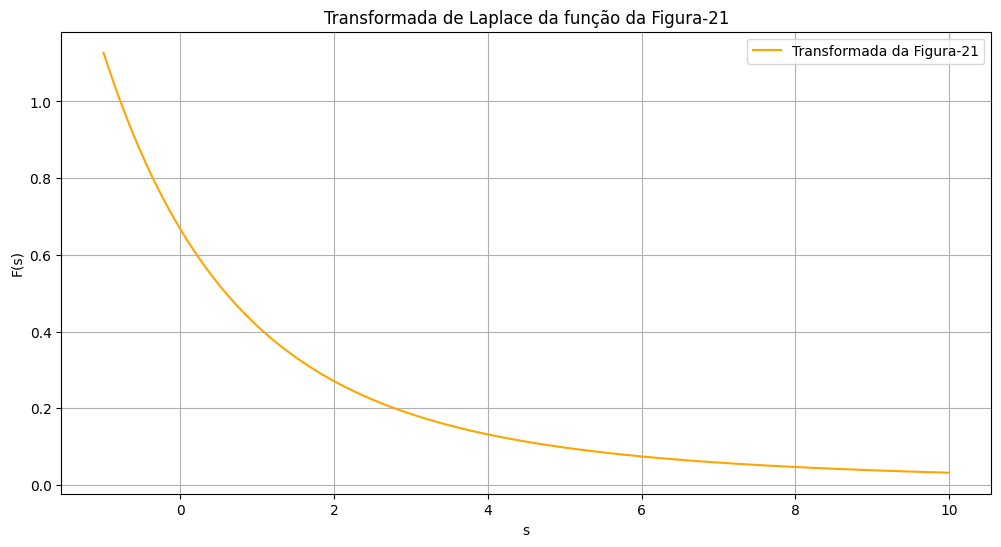

In [5]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

"""

    6. Dada a Figura 21, encontrar a Transformada de Laplace da função e reproduzi-la em
    MatLab. (usaremos python)

"""
"""
    Começa em 0(t=0), atinge 1 (t=0.5) e volta a 0(t=1) e permanece em 0.
    f(t) = at(t-1), para os zeros estarem em t=0 e t=1.
    f(0.5) = 1 => a*0.5*(0.5-1) = 1 => a = -4
    f(t) = -4t(t-1) = -4t^2 + 4t
    E só existe no intervalo entre 0 e 1, ou seja,
    f(t) = -4t^2 + 4t para 0 <= t <= 1 e f(t) = 0 para t < 0 ou t > 1

    Com isso vamos calcular a integral para a transformada de laplace.
"""

# Simbolos
t, s = sp.symbols('t s')

# Função
f = -4*t**2 + 4*t

# Transformada de Laplace
F = sp.integrate(f*sp.exp(-s*t), (t, 0, 1))

F = sp.factor(F)
print("Transformada de Laplace F(s):\n")
sp.pprint(F)

# Toma a transformada numericamente
F1 = sp.lambdify(s, F, 'numpy')

s1 = np.linspace(-1,10,1000)

# Plotagem
plt.figure("Exercício 6", figsize=(12, 6))
plt.plot(s1, F1(s1), label="Transformada da Figura-21", color='orange')
plt.xlabel('s')
plt.ylabel('F(s)')
plt.title('Transformada de Laplace da função da Figura-21')
plt.grid(True)
plt.legend()
plt.show()

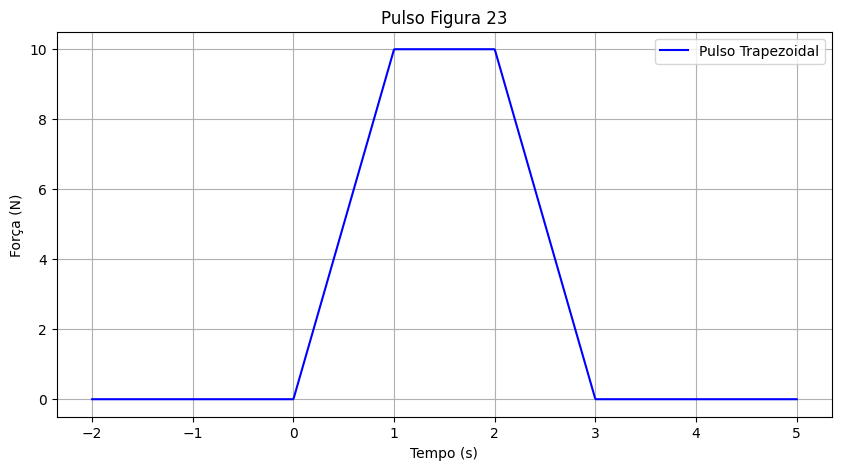

In [6]:
import numpy as np
import sympy as sp
from scipy import signal
import matplotlib.pyplot as plt

"""

    7. Na Figura 22 são apresentados alguns forçamentos que podem ser
    obtidos a partir de combinações de outros forçamentos.

    Com base na Figura 22, gerar o pulso trapezoidal conforme ilustrado
    na Figura 23 usando o prompt do MatLab, onde F0 = 10N, t1 = 1s,
    t2 = 2s, t3 = 2s. (vamo assumir t3 = 3s, para que faça sentido).
    (usaremos python)

"""
#Parâmetros
t  = np.linspace(-2, 5, 1000)  # Tempo de 0 a 5 segundos
F0 = 10
t1 = 1
t2 = 2
t3 = 3

f = np.zeros_like(t)  # Inicializa com função de zeros

mask1 = (t >= 0) & (t < t1) # degrau para subida
f[mask1] = (F0 / t1) * t[mask1]  # Subida

mask2 = (t >= t1) & (t < t2) # degrau para platô
f[mask2] = F0  # Platô

mask3 = (t >= t2) & (t < t3) # degrau para descida
f[mask3] = F0 * (t3 - t[mask3])/(t3 - t2)  # Descida

# Plotando o resultado
plt.figure("exercício 7", figsize=(10, 5))
plt.plot(t, f, label='Pulso Trapezoidal', color='blue')
plt.title('Pulso Figura 23')
plt.xlabel('Tempo (s)')
plt.ylabel('Força (N)')
plt.grid()
plt.legend()

plt.show()